# XGBoost Regressor - Solar Wastage
Train and evaluate an XGBRegressor model using features_regression_ready.csv.

In [7]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 475.5 kB/s eta 0:03:33
   ---------------------------------------- 0.5/101.7 MB 475.5 kB/s eta 0:03:33
   ---------------------------------------- 0.5/101.7 MB 475.5 kB/s eta 0:03:33
   ---------------------------------------- 0.8/101.7 MB 472.3 kB/s eta 0:03:34
   ---------------------------------------- 0.8/101.7 MB 472.3 kB/s eta 0:03:34
   ---------------------------------------- 1.0/101.7 MB 470.1 kB/s eta 0:03:35
   ---------------------------------------- 1.0/101.7 MB 470.1 kB/s eta 0:03:35
   -----------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 487.1 kB/s eta 0:03:28
   ---------------------------------------- 0.5/101.7 MB 487.1 kB/s eta 0:03:28
   ---------------------------------------- 0.8/101.7 MB 480.8 kB/s eta 0:03:30
   ---------------------------------------- 0.8/101.7 MB 480.8 kB/s eta 0:03:30
   ---------------------------------------- 0.8/101.7 MB 480.8 kB/s eta 0:03:30
   ------------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
import json
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

In [9]:
# Define file paths (relative to notebooks/training/)
DATA_PATH = Path('../../data/processed/features_regression_ready.csv')  # Input data
MODEL_PATH = Path('../../models/xgboost_pipeline.pkl')  # Output model
METRICS_PATH = Path('../../models/xgboost_metrics.json')  # Output metrics
RANDOM_STATE = 42  # For reproducibility

In [10]:
# Load and prepare data
df = pd.read_csv(DATA_PATH)
target_col = 'wasted_energy_kwh'  # Target variable to predict

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Define column types for preprocessing
categorical_cols = ['household', 'season', 'district']
numerical_cols = [c for c in X.columns if c not in categorical_cols]
X.head()

,daily_pv_kwh,daily_load_kwh,household,year,month,day,quarter,day_of_week,day_of_year,week_of_year,...,load_rolling_mean_14d,pv_rolling_std_14d,wastage_rolling_mean_14d,pv_rolling_mean_30d,load_rolling_mean_30d,pv_rolling_std_30d,wastage_rolling_mean_30d,district,irradiance,temp
0,0.010838,0.018602,residential1,2015,5,21,2,3,141,21,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,Colombo,5.6695,26.91
1,0.555957,0.214720,residential1,2015,5,22,2,4,142,21,...,0.018602,0.000000,0.0,0.010838,0.018602,0.000000,0.0,Colombo,6.0698,27.17
2,1.382767,0.409031,residential1,2015,5,23,2,5,143,21,...,0.116661,0.385457,0.0,0.283398,0.116661,0.385457,0.0,Colombo,4.5922,27.20
3,2.177085,0.574465,residential1,2015,5,24,2,6,144,21,...,0.214118,0.690768,0.0,0.649854,0.214118,0.690768,0.0,Colombo,6.2059,27.32
4,2.962496,0.684174,residential1,2015,5,25,2,0,145,22,...,0.304204,0.949324,0.0,1.031662,0.304204,0.949324,0.0,Colombo,6.1730,27.30


In [11]:
# Define preprocessing pipelines for different column types
# Categorical: impute missing values with most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Numerical: impute missing values with median, then standardize
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combine transformers into a single preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_cols),
    ('num', numerical_transformer, numerical_cols)
])

In [12]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [13]:
# Create XGBoost regressor model with tuned hyperparameters
model = XGBRegressor(
    n_estimators=400,        # Number of boosting rounds
    max_depth=6,             # Maximum tree depth
    learning_rate=0.05,      # Step size shrinkage
    subsample=0.8,           # Subsample ratio of training data
    colsample_bytree=0.8,    # Subsample ratio of columns per tree
    random_state=RANDOM_STATE,
    n_jobs=-1,               # Use all CPU cores
    objective='reg:squarederror'
)

# Build pipeline: preprocessing -> model
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

# Train the model and make predictions
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [14]:
# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)            # R-squared (coefficient of determination)
mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
rmse = root_mean_squared_error(y_test, y_pred)  # Root Mean Squared Error

# Display results
print('XGBRegressor Results')
print('=' * 50)
print(f'R2:   {r2:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

XGBRegressor Results
R2:   0.9986
MAE:  0.5069
RMSE: 4.8241


In [15]:
# Save metrics and trained model
metrics = {'R2': float(r2), 'MAE': float(mae), 'RMSE': float(rmse)}

# Create models directory if it doesn't exist
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save pipeline (includes preprocessor + model)
joblib.dump(pipeline, MODEL_PATH)

# Save metrics as JSON
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print('Saved:', MODEL_PATH, METRICS_PATH)

Saved: ..\..\models\xgboost_pipeline.pkl ..\..\models\xgboost_metrics.json


## Plot Actual vs Predicted

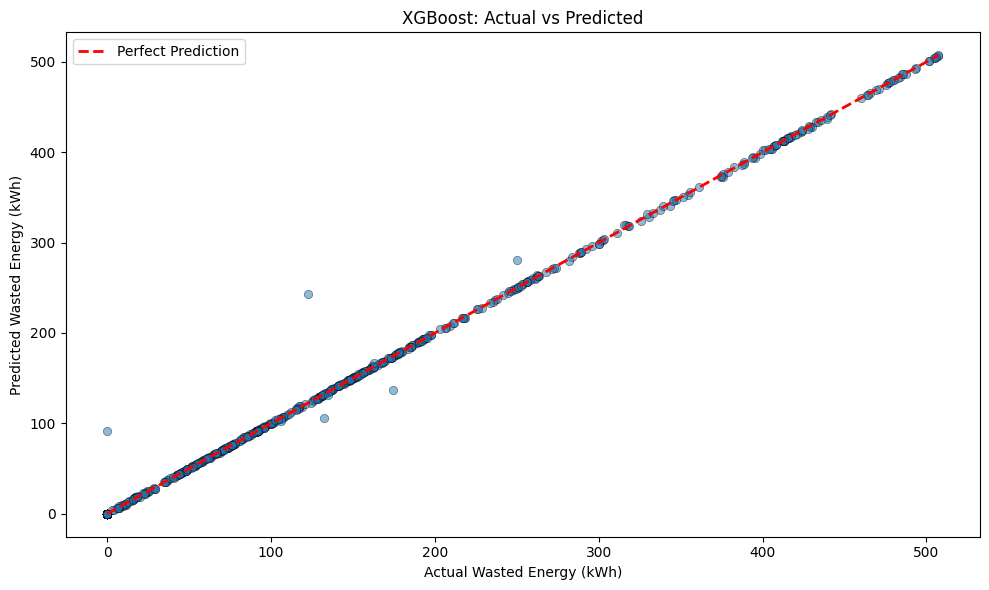

In [16]:
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Wasted Energy (kWh)')
plt.ylabel('Predicted Wasted Energy (kWh)')
plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig('../../results/xgboost_actual_vs_predicted.png', dpi=150)
plt.show()

## Feature Importance

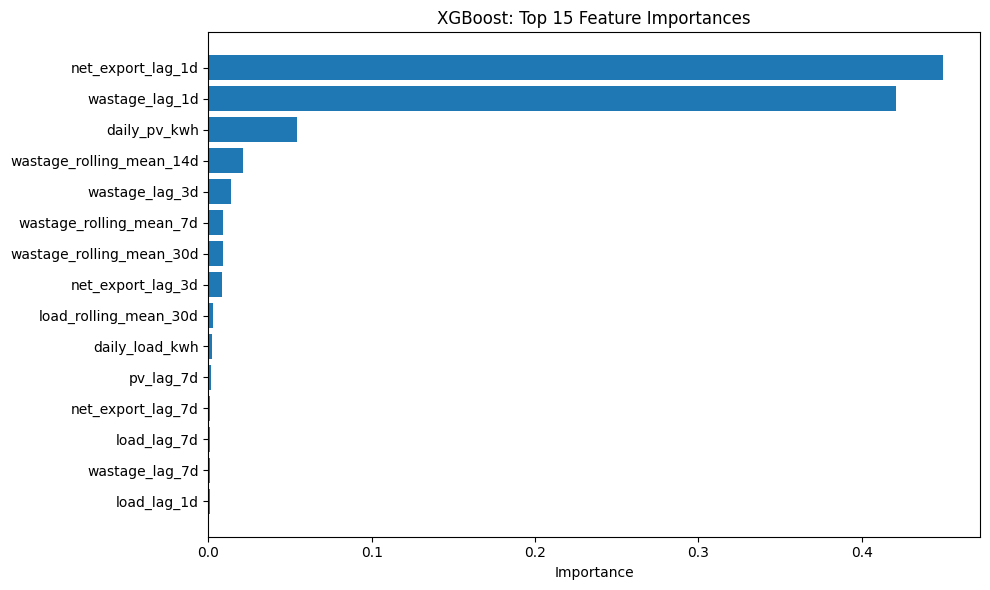

In [17]:
# Extract feature names after one-hot encoding
cat_features = pipeline.named_steps['preprocessor'].named_transformers_['cat']\
    .named_steps['onehot'].get_feature_names_out(categorical_cols).tolist()
all_features = cat_features + numerical_cols

# Get feature importances from the trained model
importances = pipeline.named_steps['model'].feature_importances_

# Create DataFrame and sort by importance
feat_imp = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('XGBoost: Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('../../results/xgboost_feature_importance.png', dpi=150)
plt.show()

## Prediction Function

In [18]:
def predict_wastage(new_data_dict, model_path=MODEL_PATH):
    """
    Predict solar energy wastage from input features using the trained XGBoost model.
    
    Parameters:
    -----------
    new_data_dict : dict
        Dictionary containing feature values. Missing features default to 0.
    model_path : Path
        Path to the saved model pipeline.
        
    Returns:
    --------
    float : Predicted wasted energy in kWh.
    """
    # Get feature names from training data
    feature_names = X.columns.tolist()
    
    # Initialize all features with default value 0
    row = {name: 0.0 for name in feature_names}
    
    # Update with user-provided values
    for key, value in new_data_dict.items():
        if key in row:
            row[key] = value
    
    # Convert to DataFrame and predict
    input_df = pd.DataFrame([row])
    loaded_pipeline = joblib.load(model_path)
    prediction = loaded_pipeline.predict(input_df)[0]
    
    return max(0.0, float(prediction))


# Example usage
example_input = {
    'household': 'household_0',
    'season': 'summer',
    'district': 'Colombo',
    'solar_generated_kwh': 15.0,
    'consumption_kwh': 10.0
}
predicted_wastage = predict_wastage(example_input)
print(f"Predicted wasted energy: {predicted_wastage:.4f} kWh")

Predicted wasted energy: 0.0113 kWh
